# Meridian MMM Demo

실제 매출 데이터 + 가상 미디어 데이터를 사용한 Meridian v1.5.1 데모

**주의**: 이 분석은 가상의 미디어 지출 데이터를 사용합니다. 실제 분석에서는 실제 미디어 채널별 지출 데이터를 사용하세요!

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("Libraries loaded")

Libraries loaded


## 1. 데이터 로드 및 전처리

In [2]:
# 원본 데이터 로드
df = pd.read_csv('/Users/ansaejin/Desktop/lambda_api/hello_world/uploads/2/csv/custom.csv')
print(f"Total rows: {len(df):,}")
print(f"Date range: {df['date'].min()} ~ {df['date'].max()}")
print(f"Unique stores: {df['store_code'].nunique()}")
df.head()

Total rows: 629,298
Date range: 2023-01-01 ~ 2026-03-08
Unique stores: 125


,sales_code,txn_id,date,barcode,style_code,style_name,store_code,store_kr,sold_price,sold_quantity,...,store,sales_type1,sales_type2,sales_type3,channel_type,country,trade,distribution,operation,format
0,20230101GW000111001000503,11001,2023-01-01,G20WMC1DJ01DGRXL,G20WMC1DJ01,REVERSIBLE GOOSE LONG DOWN JACKET,GW0001,가로수길 플래그십,155600,1,...,FLAGSHIP,retail,offline,owned,owned,korea,RETAIL,OFFLINE,OWNED,STREET
1,20230101GW000111002000504,11002,2023-01-01,G2XSL201#BK280,G2XSL201,GRAB-ITY BALANCE™ PRO CLOG,GW0001,가로수길 플래그십,45000,1,...,FLAGSHIP,retail,offline,owned,owned,korea,RETAIL,OFFLINE,OWNED,STREET
2,20230101GW000111003000505,11003,2023-01-01,G2FPT101LPKXS,G2FPT101,SIGNATURE ESSENTIAL JOGGER,GW0001,가로수길 플래그십,55300,1,...,FLAGSHIP,retail,offline,owned,owned,korea,RETAIL,OFFLINE,OWNED,STREET
3,20230101GW000111003000506,11003,2023-01-01,G2WDJ102#BGS,G2WDJ102,EMBO REVERSIBLE DOWN JACKET,GW0001,가로수길 플래그십,209300,1,...,FLAGSHIP,retail,offline,owned,owned,korea,RETAIL,OFFLINE,OWNED,STREET
4,20230101GW000111003000507,11003,2023-01-01,G2WDJ102#BKM,G2WDJ102,EMBO REVERSIBLE DOWN JACKET,GW0001,가로수길 플래그십,209300,1,...,FLAGSHIP,retail,offline,owned,owned,korea,RETAIL,OFFLINE,OWNED,STREET


In [3]:
# 날짜 변환 및 주차 생성
df['date'] = pd.to_datetime(df['date'])
df['week'] = df['date'].dt.to_period('W').apply(lambda x: x.start_time)

# 주간 매출 집계 (전체 geo 단일화 - national level)
weekly_sales = df.groupby('week').agg({
    'sales_amount': 'sum',
    'sold_quantity': 'sum'
}).reset_index()

weekly_sales.columns = ['week', 'revenue', 'units']
weekly_sales = weekly_sales.sort_values('week').reset_index(drop=True)

print(f"Weekly data points: {len(weekly_sales)}")
print(f"Total revenue: {weekly_sales['revenue'].sum()/1e9:.2f}B KRW")
weekly_sales.head(10)

Weekly data points: 167
Total revenue: 89.58B KRW


,week,revenue,units
0,2022-12-26,23763575,374
1,2023-01-02,305436333,6068
2,2023-01-09,527922197,10471
3,2023-01-16,778383062,10904
4,2023-01-23,305954207,4031
5,2023-01-30,837512880,12010
6,2023-02-06,437249438,6993
7,2023-02-13,490504439,7443
8,2023-02-20,263435537,4945
9,2023-02-27,424816954,8363


## 2. 가상 미디어 데이터 생성

**주의**: 실제 분석에서는 실제 미디어 지출 데이터를 사용해야 합니다!

In [4]:
np.random.seed(42)
n_weeks = len(weekly_sales)

# 매출 패턴을 기반으로 상관관계 있는 가상 미디어 데이터 생성
revenue_normalized = (weekly_sales['revenue'] - weekly_sales['revenue'].min()) / (weekly_sales['revenue'].max() - weekly_sales['revenue'].min())

# 가상 미디어 채널별 지출
weekly_sales['tv_spend'] = (revenue_normalized * 50000000 + np.random.normal(0, 5000000, n_weeks)).clip(1000000, 100000000).astype(int)
weekly_sales['digital_spend'] = (revenue_normalized * 30000000 + np.random.normal(0, 3000000, n_weeks)).clip(500000, 50000000).astype(int)
weekly_sales['search_spend'] = (revenue_normalized * 20000000 + np.random.normal(0, 2000000, n_weeks)).clip(500000, 30000000).astype(int)

# 시즌성 추가 (겨울에 더 많은 광고)
weekly_sales['month'] = pd.to_datetime(weekly_sales['week']).dt.month
winter_boost = weekly_sales['month'].apply(lambda x: 1.3 if x in [11, 12, 1, 2] else 1.0)
weekly_sales['tv_spend'] = (weekly_sales['tv_spend'] * winter_boost).astype(int)
weekly_sales.drop('month', axis=1, inplace=True)

print("Media spend per week (avg):")
print(f"  TV: {weekly_sales['tv_spend'].mean()/1e6:.1f}M KRW")
print(f"  Digital: {weekly_sales['digital_spend'].mean()/1e6:.1f}M KRW")
print(f"  Search: {weekly_sales['search_spend'].mean()/1e6:.1f}M KRW")

Media spend per week (avg):
  TV: 8.3M KRW
  Digital: 4.6M KRW
  Search: 3.0M KRW


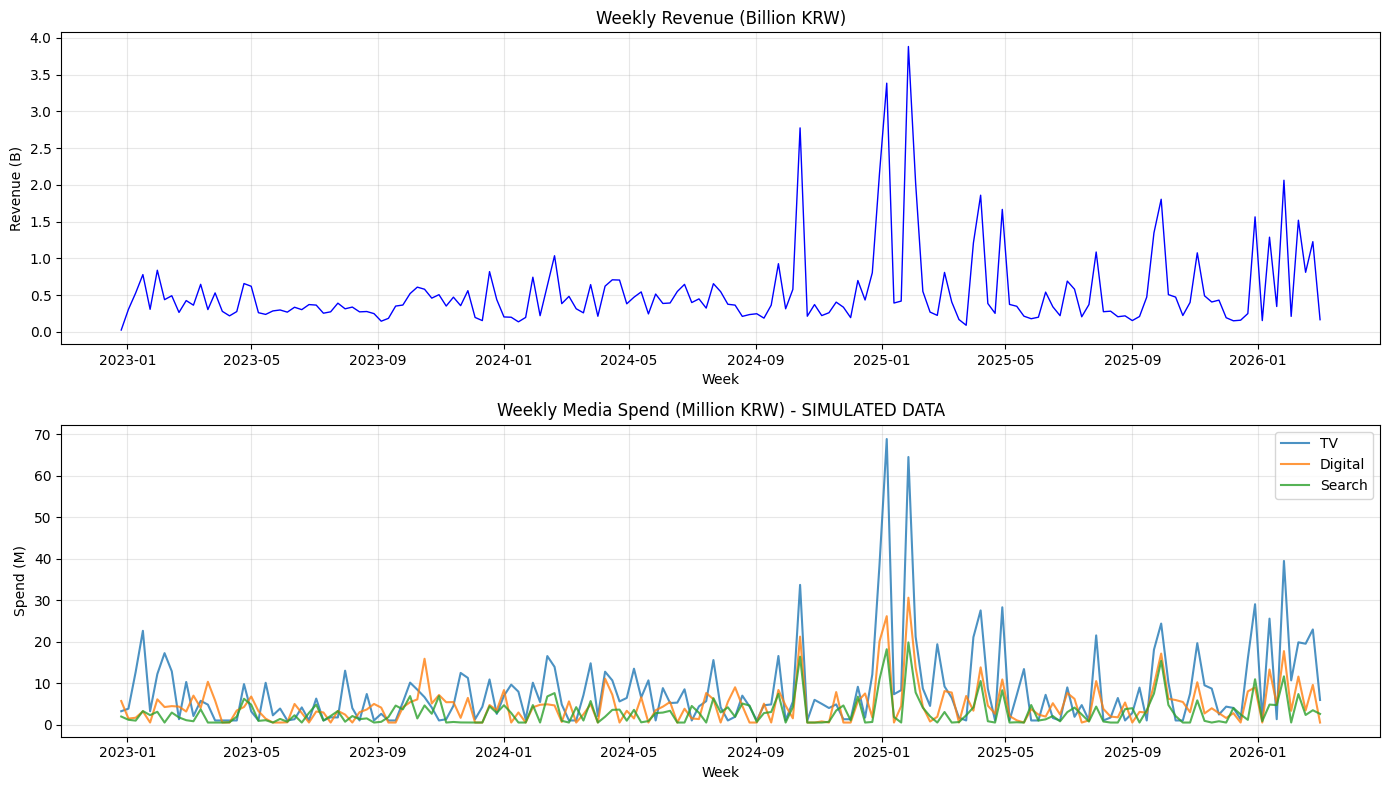

In [5]:
# 데이터 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 매출 추이
axes[0].plot(weekly_sales['week'], weekly_sales['revenue'] / 1e9, 'b-', linewidth=1)
axes[0].set_title('Weekly Revenue (Billion KRW)')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Revenue (B)')
axes[0].grid(True, alpha=0.3)

# 미디어 지출 추이
axes[1].plot(weekly_sales['week'], weekly_sales['tv_spend'] / 1e6, label='TV', alpha=0.8)
axes[1].plot(weekly_sales['week'], weekly_sales['digital_spend'] / 1e6, label='Digital', alpha=0.8)
axes[1].plot(weekly_sales['week'], weekly_sales['search_spend'] / 1e6, label='Search', alpha=0.8)
axes[1].set_title('Weekly Media Spend (Million KRW) - SIMULATED DATA')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Spend (M)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Meridian InputData 준비 (v1.5.1 API)

In [6]:
from meridian import constants
from meridian.data import input_data

print("Meridian loaded successfully!")

Meridian loaded successfully!


In [7]:
# Coordinates 설정
geo_names = ['national']  # 단일 geo (national level)
time_coords = [t.strftime('%Y-%m-%d') for t in pd.to_datetime(weekly_sales['week'])]  # 문자열 형식!
media_channels = ['TV', 'Digital', 'Search']

n_geos = len(geo_names)
n_times = len(time_coords)
n_media = len(media_channels)

# KPI DataArray (shape: geo x time)
kpi_da = xr.DataArray(
    data=weekly_sales['revenue'].values.reshape(n_geos, n_times).astype(np.float32),
    dims=['geo', 'time'],
    coords={'geo': geo_names, 'time': time_coords},
    name='kpi'  # name 필수!
)

# Population DataArray (shape: geo)
population_da = xr.DataArray(
    data=np.array([1.0], dtype=np.float32),
    dims=['geo'],
    coords={'geo': geo_names},
    name='population'
)

# Media DataArray (shape: geo x media_time x media_channel)
media_data = np.stack([
    weekly_sales['tv_spend'].values,
    weekly_sales['digital_spend'].values,
    weekly_sales['search_spend'].values
], axis=-1).reshape(n_geos, n_times, n_media).astype(np.float32)

media_da = xr.DataArray(
    data=media_data,
    dims=['geo', 'media_time', 'media_channel'],
    coords={'geo': geo_names, 'media_time': time_coords, 'media_channel': media_channels},
    name='media'
)

# Media Spend DataArray (shape: geo x time x media_channel)
media_spend_da = xr.DataArray(
    data=media_data.copy(),
    dims=['geo', 'time', 'media_channel'],
    coords={'geo': geo_names, 'time': time_coords, 'media_channel': media_channels},
    name='media_spend'
)

print(f"KPI shape: {kpi_da.shape}")
print(f"Population shape: {population_da.shape}")
print(f"Media shape: {media_da.shape}")
print(f"Media Spend shape: {media_spend_da.shape}")

KPI shape: (1, 167)
Population shape: (1,)
Media shape: (1, 167, 3)
Media Spend shape: (1, 167, 3)


In [8]:
# InputData 객체 생성
input_data_obj = input_data.InputData(
    kpi=kpi_da,
    kpi_type=constants.REVENUE,
    population=population_da,
    media=media_da,
    media_spend=media_spend_da,
)

print("InputData created successfully!")

InputData created successfully!


## 4. 모델 생성 및 학습

**참고**: CPU에서 실행 시 약 45-60초 정도 걸립니다.

In [9]:
from meridian.model import model
from meridian.model import spec

# 모델 스펙 정의
model_spec = spec.ModelSpec()

# 모델 생성 (v1.5.1 API: input_data를 Meridian에 직접 전달)
mmm = model.Meridian(input_data=input_data_obj, model_spec=model_spec)

print("Model created successfully!")

Model created successfully!


I0000 00:00:1773739701.781478 37192462 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [10]:
# 모델 학습 (v1.5.1 API: sample_posterior 사용)
import time

print("Starting posterior sampling... (this takes ~45 seconds on CPU)")
start_time = time.time()

mmm.sample_posterior(
    n_chains=2,           # 체인 수
    n_adapt=50,           # 적응 단계
    n_burnin=50,          # 번인 단계
    n_keep=50,            # 유지할 샘플 수
    seed=42,
)

elapsed = time.time() - start_time
print(f"Completed in {elapsed:.1f} seconds")

Starting posterior sampling... (this takes ~45 seconds on CPU)
Completed in 55.6 seconds


## 5. 결과 분석

In [11]:
from meridian.analysis import analyzer

mmm_analyzer = analyzer.Analyzer(mmm)
print("Analyzer created!")

Analyzer created!


In [12]:
# ROI 분석
roi_tensor = mmm_analyzer.roi()
roi_values = roi_tensor.numpy()

print("ROI by Media Channel")
print("=" * 60)
print(f"{'Channel':12} | {'Mean ROI':>10} | {'5th':>8} | {'50th':>8} | {'95th':>8}")
print("-" * 60)

for i, channel in enumerate(media_channels):
    channel_roi = roi_values[:, :, i].flatten()
    mean = np.mean(channel_roi)
    p5 = np.percentile(channel_roi, 5)
    p50 = np.percentile(channel_roi, 50)
    p95 = np.percentile(channel_roi, 95)
    print(f"{channel:12} | {mean:10.2f} | {p5:8.2f} | {p50:8.2f} | {p95:8.2f}")

ROI by Media Channel
Channel      |   Mean ROI |      5th |     50th |     95th
------------------------------------------------------------
TV           |      45.41 |    36.14 |    44.44 |    57.95
Digital      |      70.12 |     7.91 |    75.47 |   100.07
Search       |      27.40 |     0.44 |     1.99 |   106.22


In [13]:
# Incremental Revenue 분석
incremental = mmm_analyzer.incremental_outcome()
inc_values = incremental.numpy()

print("Incremental Revenue by Media Channel")
print("=" * 70)
print(f"{'Channel':12} | {'Mean':>12} | {'5th':>12} | {'50th':>12} | {'95th':>12}")
print("-" * 70)

for i, channel in enumerate(media_channels):
    channel_inc = inc_values[:, :, i].flatten()
    mean = np.mean(channel_inc)
    p5 = np.percentile(channel_inc, 5)
    p50 = np.percentile(channel_inc, 50)
    p95 = np.percentile(channel_inc, 95)
    print(f"{channel:12} | {mean/1e9:10.2f}B | {p5/1e9:10.2f}B | {p50/1e9:10.2f}B | {p95/1e9:10.2f}B")

Incremental Revenue by Media Channel
Channel      |         Mean |          5th |         50th |         95th
----------------------------------------------------------------------
TV           |      62.66B |      49.87B |      61.33B |      79.97B
Digital      |      54.02B |       6.10B |      58.14B |      77.10B
Search       |      13.54B |       0.22B |       0.98B |      52.50B


In [14]:
# Summary
total_spend = weekly_sales[['tv_spend', 'digital_spend', 'search_spend']].sum().sum()
total_revenue = weekly_sales['revenue'].sum()

print("\nModel Summary")
print("=" * 40)
print(f"Total Media Spend: {total_spend/1e9:.2f}B KRW")
print(f"Total Revenue: {total_revenue/1e9:.2f}B KRW")
print(f"Data Period: {time_coords[0]} ~ {time_coords[-1]}")
print(f"Number of Weeks: {len(time_coords)}")


Model Summary
Total Media Spend: 2.64B KRW
Total Revenue: 89.58B KRW
Data Period: 2022-12-26 ~ 2026-03-02
Number of Weeks: 167


## 주의사항

**이 분석은 가상의 미디어 데이터를 사용했습니다!**

실제 MMM 분석을 위해서는:
1. 실제 미디어 채널별 지출 데이터가 필요합니다
2. 충분한 기간의 데이터 (최소 2년 권장)
3. 통제 변수 (프로모션, 휴일, 가격 등) 추가 권장
4. GPU 환경에서 더 많은 MCMC 샘플로 학습 권장

### 참고 자료
- [Meridian GitHub](https://github.com/google/meridian)
- [Meridian Documentation](https://developers.google.com/meridian)
- [Data Format Guide](https://developers.google.com/meridian/docs/user-guide/data-format)